In [292]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import holidays


pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [293]:
filename = 'data/encoded_netgen.csv'
df = pd.read_csv(filename)


In [294]:
start_date = "2025-01-01 01:00:00"
end_date   = "2026-04-12 23:00:00"
# determine the train test split at the same time 
train_date = "2026-01-01"

df["DateTime(UTC)"] = pd.to_datetime(df["DateTime(UTC)"])
df = df.sort_values("DateTime(UTC)")
df = df.set_index("DateTime(UTC)")
df_truncated = df.loc[start_date:end_date]
df_truncated = df_truncated.reset_index()


In [295]:
df_truncated.head()

,DateTime(UTC),other,other_renewable,stable,variable
0,2025-01-01 01:00:00,211.50,97.99,14057.98,37800.97
1,2025-01-01 01:15:00,211.88,98.11,13551.27,37924.39
2,2025-01-01 01:30:00,211.75,98.16,13151.61,37659.50
3,2025-01-01 01:45:00,211.70,98.09,12851.14,37573.42
4,2025-01-01 02:00:00,211.92,97.77,13630.51,35874.70


In [296]:
# ---- Basic time features ----
df_truncated["day_of_week"] = df_truncated["DateTime(UTC)"].dt.dayofweek
df_truncated["day_of_year"] = df_truncated["DateTime(UTC)"].dt.dayofyear
df_truncated["month"] = df_truncated["DateTime(UTC)"].dt.month
df_truncated["year"] = df_truncated["DateTime(UTC)"].dt.year

# ---- Hour + quarter-hour ----
df_truncated["hour"] = df_truncated["DateTime(UTC)"].dt.hour

# quarter of hour: 0,1,2,3
df_truncated["quarter_hour"] = df_truncated["DateTime(UTC)"].dt.minute // 15

# ---- German public holidays ----
years = df_truncated["year"].unique()
de_holidays = holidays.Germany(years=years)

df_truncated["is_holiday"] = df_truncated["DateTime(UTC)"].dt.floor("D").isin(de_holidays)

# ---- Bridge day (Brückentag) ----
# A bridge day is typically:
# - Monday before a Tuesday holiday
# - Friday after a Thursday holiday

df_truncated["date"] = df_truncated["DateTime(UTC)"].dt.date

holidays_set = set(de_holidays)

def is_bridge_day(date):
    weekday = date.weekday()
    
    # Monday before Tuesday holiday
    if weekday == 0 and (date + pd.Timedelta(days=1)) in holidays_set:
        return 1
    
    # Friday after Thursday holiday
    if weekday == 4 and (date - pd.Timedelta(days=1)) in holidays_set:
        return 1
    
    return 0

df_truncated["is_bridge_day"] = df_truncated["date"].apply(is_bridge_day)

# convert holiday boolean to int
df_truncated["is_holiday"] = df_truncated["is_holiday"].astype(int)

/tmp/ipykernel_1523/1771040005.py:17: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_truncated["is_holiday"] = df_truncated["DateTime(UTC)"].dt.floor("D").isin(de_holidays)


In [297]:
# add stable stats column
# Rolling mean
df_truncated["stable_roll_mean_4"] = df_truncated["stable"].rolling(4).mean()
df_truncated["stable_roll_mean_24"] = df_truncated["stable"].rolling(24).mean()
df_truncated["stable_roll_mean_96"] = df_truncated["stable"].rolling(96).mean()
df_truncated["stable_roll_mean_672"] = df_truncated["stable"].rolling(672).mean()

# Rolling std
df_truncated["stable_roll_std_4"] = df_truncated["stable"].rolling(4).std()
df_truncated["stable_roll_std_24"] = df_truncated["stable"].rolling(24).std()
df_truncated["stable_roll_std_96"] = df_truncated["stable"].rolling(96).std()

df_truncated["stable_lag_1"] = df_truncated["stable"].shift(1)
df_truncated["stable_lag_4"] = df_truncated["stable"].shift(4)
df_truncated["stable_lag_12"] = df_truncated["stable"].shift(12)   # 3 hours
df_truncated["stable_lag_24"] = df_truncated["stable"].shift(24)   # 6 hours
df_truncated["stable_lag_96"] = df_truncated["stable"].shift(96)   # 1 day
df_truncated["stable_lag_672"] = df_truncated["stable"].shift(672) # 1 week



In [298]:
# add variable stats column
# Rolling mean
df_truncated["variable_roll_mean_4"] = df_truncated["variable"].rolling(4).mean()
df_truncated["variable_roll_mean_24"] = df_truncated["variable"].rolling(24).mean()
df_truncated["variable_roll_mean_96"] = df_truncated["variable"].rolling(96).mean()
df_truncated["variable_roll_mean_672"] = df_truncated["variable"].rolling(672).mean()

# Rolling std
df_truncated["variable_roll_std_4"] = df_truncated["variable"].rolling(4).std()
df_truncated["variable_roll_std_24"] = df_truncated["variable"].rolling(24).std()
df_truncated["variable_roll_std_96"] = df_truncated["variable"].rolling(96).std()

df_truncated["variable_lag_1"] = df_truncated["variable"].shift(1)
df_truncated["variable_lag_4"] = df_truncated["variable"].shift(4)
df_truncated["variable_lag_12"] = df_truncated["variable"].shift(12)   # 3 hours
df_truncated["variable_lag_24"] = df_truncated["variable"].shift(24)   # 6 hours
df_truncated["variable_lag_96"] = df_truncated["variable"].shift(96)   # 1 day
df_truncated["variable_lag_672"] = df_truncated["variable"].shift(672) # 1 week

In [299]:
# Net Generation data is done now. Now process target column
df_y = pd.read_csv('data/combined_energy_price_clean.csv', sep='\t')
df_y["DateTime(UTC)"] = pd.to_datetime(df_y["DateTime(UTC)"])
df_y = df_y.sort_values("DateTime(UTC)")
df_y = df_y.set_index("DateTime(UTC)")
df_y_truncated = df_y.loc[start_date:end_date]
df_y_truncated = df_y_truncated.reset_index()
df_y_truncated = df_y_truncated[df_y_truncated["Sequence"] != 1]

/tmp/ipykernel_1523/1455107288.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_y = pd.read_csv('data/combined_energy_price_clean.csv', sep='\t')


In [300]:
# now we add oil and gas price, hopefully we can predict the peak
filename = 'data/oil_gas_prices.csv'
df_oil_gas = pd.read_csv(filename)

# Ensure period is datetime
df_oil_gas["period"] = pd.to_datetime(df_oil_gas["period"])
df_oil_gas = df_oil_gas.sort_values("period")

# Define range to REMOVE
start_date_remove = "2006-01-01"
end_date_remove = "2021-12-31"

# reduce some columns first
df_oil_gas = df_oil_gas[
    ~df_oil_gas["period"].between(start_date_remove, end_date_remove)
]

df_oil_gas = df_oil_gas.reset_index(drop=True)

# Ensure date column is datetime
df_oil_gas["period"] = pd.to_datetime(df_oil_gas["period"])

# Set index
df_oil_gas = df_oil_gas.set_index("period").sort_index()

# Create full daily date range
full_range = pd.date_range(start=df_oil_gas.index.min(), end=df_oil_gas.index.max(), freq="D")

# Reindex to include missing days (weekends/holidays)
df_oil_gas = df_oil_gas.reindex(full_range)

# Fill missing values with previous day's price
df_oil_gas = df_oil_gas.ffill()

df_oil_gas.index.name = "DateTime(UTC)"
df_oil_gas = df_oil_gas.reset_index()
df_oil_gas.head()

,DateTime(UTC),WTI_Oil,Brent_Oil,Natural_Gas
0,2022-01-03,75.99,78.25,3.74
1,2022-01-04,77.00,79.39,3.73
2,2022-01-05,77.83,80.60,3.78
3,2022-01-06,79.47,81.99,3.94
4,2022-01-07,79.00,82.28,3.83


In [301]:
# Ensure datetime format
df_oil_gas["DateTime(UTC)"] = pd.to_datetime(df_oil_gas["DateTime(UTC)"])

# Set datetime as index
df_oil_gas = df_oil_gas.set_index("DateTime(UTC)")

# Upsample to 15-minute frequency
df_oil_gas = df_oil_gas.resample("15min").ffill()

# Reset index if needed
df_oil_gas = df_oil_gas.reset_index()


df_oil_gas = df_oil_gas.set_index("DateTime(UTC)")
df_oil_gas = df_oil_gas.ffill()
df_oil_gas_truncated = df_oil_gas.loc[start_date:end_date]
df_oil_gas_truncated = df_oil_gas_truncated.reset_index()

In [302]:
df_oil_gas_truncated.head(), df_oil_gas_truncated.isna().any().any()

(        DateTime(UTC)  WTI_Oil  Brent_Oil  Natural_Gas
 0 2025-01-01 01:00:00    72.44      74.58          3.4
 1 2025-01-01 01:15:00    72.44      74.58          3.4
 2 2025-01-01 01:30:00    72.44      74.58          3.4
 3 2025-01-01 01:45:00    72.44      74.58          3.4
 4 2025-01-01 02:00:00    72.44      74.58          3.4,
 False)

In [303]:
# tested with oil and gas price, seems like not much impact
# now we add load data

filename = 'data/load_data.csv'
df_load = pd.read_csv(filename)

df_load = df_load.rename(columns={"Unnamed: 0": "DateTime(UTC)"})

# Step 1: ensure string and remove last 6 chars
df_load["DateTime(UTC)"] = df_load["DateTime(UTC)"].astype(str).str[:-6]

# Step 2: convert to datetime
df_load["DateTime(UTC)"] = pd.to_datetime(df_load["DateTime(UTC)"], errors="coerce")

# Step 3: subtract 1 hour
# convert to utc 
df_load["DateTime(UTC)"] = df_load["DateTime(UTC)"] - pd.Timedelta(hours=1)

# df_load["DateTime(UTC)"] = pd.to_datetime(df["DateTime(UTC)"])
df_load = df_load.sort_values("DateTime(UTC)")
df_load = df_load.set_index("DateTime(UTC)")
df_load_truncated = df_load.loc[start_date:end_date]
df_load_truncated = df_load_truncated.reset_index()
df_load_truncated.drop_duplicates(inplace=True)

# There are duplicated timestep with different valaues, lets take the average for those timesteps
df_load_truncated = (
    df_load_truncated
    .groupby('DateTime(UTC)', as_index=False)['load']
    .mean()
)

# There are missing time step during the day end of march day light saving
# due to laod data is in berlin time zone
# lets fill those missing timestep with previous values
df_load_truncated = df_load_truncated.set_index('DateTime(UTC)').sort_index()
full_range = pd.date_range(
    start=df_load_truncated.index.min(),
    end=df_load_truncated.index.max(),
    freq='15min'
)
df_load_truncated = df_load_truncated.reindex(full_range).ffill()
df_load_truncated = df_load_truncated.reset_index().rename(columns={'index': 'DateTime(UTC)'})

df_load_truncated.head()

,DateTime(UTC),load
0,2025-01-01 01:00:00,46687.66
1,2025-01-01 01:15:00,46309.86
2,2025-01-01 01:30:00,46082.62
3,2025-01-01 01:45:00,45894.49
4,2025-01-01 02:00:00,45329.16


In [304]:
df_truncated.shape, df_load_truncated.shape, df_load_truncated['DateTime(UTC)'].duplicated().any()

((44825, 40), (44825, 2), False)

In [305]:

diff1 = df_truncated['DateTime(UTC)'][~df_truncated['DateTime(UTC)'].isin(df_load_truncated['DateTime(UTC)'])]
diff2 = df_load_truncated['DateTime(UTC)'][~df_load_truncated['DateTime(UTC)'].isin(df_truncated['DateTime(UTC)'])]

print("Only in df1:\n", diff1)
print("Only in df2:\n", diff2)

(df_load_truncated["DateTime(UTC)"].to_numpy() ==
 df_truncated["DateTime(UTC)"].to_numpy()).all()

Only in df1:
 Series([], Name: DateTime(UTC), dtype: datetime64[ns])
Only in df2:
 Series([], Name: DateTime(UTC), dtype: datetime64[ns])


True

In [306]:
#now we checked that all dataframes have the same datetime, we can combine them 

df_merged = df_truncated.merge(
    df_y_truncated[["DateTime(UTC)", "Price[Currency/MWh]"]],
    on="DateTime(UTC)",
    how="left"
)

df_merged = df_merged.merge(
    df_oil_gas_truncated[["DateTime(UTC)", "WTI_Oil", "Brent_Oil", "Natural_Gas"]],
    on="DateTime(UTC)",
    how="left"
)

# df_merged = df_merged.merge(
#     df_load_truncated[["DateTime(UTC)", "load"]],
#     on="DateTime(UTC)",
#     how="left"
# )

df_merged.head()

,DateTime(UTC),other,other_renewable,stable,variable,day_of_week,day_of_year,month,year,hour,quarter_hour,is_holiday,date,is_bridge_day,stable_roll_mean_4,stable_roll_mean_24,stable_roll_mean_96,stable_roll_mean_672,stable_roll_std_4,stable_roll_std_24,stable_roll_std_96,stable_lag_1,stable_lag_4,stable_lag_12,stable_lag_24,stable_lag_96,stable_lag_672,variable_roll_mean_4,variable_roll_mean_24,variable_roll_mean_96,variable_roll_mean_672,variable_roll_std_4,variable_roll_std_24,variable_roll_std_96,variable_lag_1,variable_lag_4,variable_lag_12,variable_lag_24,variable_lag_96,variable_lag_672,Price[Currency/MWh],WTI_Oil,Brent_Oil,Natural_Gas
0,2025-01-01 01:00:00,211.50,97.99,14057.98,37800.97,2,1,1,2025,1,0,1,2025-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.60,72.44,74.58,3.4
1,2025-01-01 01:15:00,211.88,98.11,13551.27,37924.39,2,1,1,2025,1,1,1,2025-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14057.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37800.97,NaN,NaN,NaN,NaN,NaN,-0.50,72.44,74.58,3.4
2,2025-01-01 01:30:00,211.75,98.16,13151.61,37659.50,2,1,1,2025,1,2,1,2025-01-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13551.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37924.39,NaN,NaN,NaN,NaN,NaN,-6.51,72.44,74.58,3.4
3,2025-01-01 01:45:00,211.70,98.09,12851.14,37573.42,2,1,1,2025,1,3,1,2025-01-01,0,13403.0000,NaN,NaN,NaN,522.407627,NaN,NaN,13151.61,NaN,NaN,NaN,NaN,NaN,37739.5700,NaN,NaN,NaN,154.860604,NaN,NaN,37659.50,NaN,NaN,NaN,NaN,NaN,-3.50,72.44,74.58,3.4
4,2025-01-01 02:00:00,211.92,97.77,13630.51,35874.70,2,1,1,2025,2,0,1,2025-01-01,0,13296.1325,NaN,NaN,NaN,363.230200,NaN,NaN,12851.14,14057.98,NaN,NaN,NaN,NaN,37258.0025,NaN,NaN,NaN,934.217417,NaN,NaN,37573.42,37800.97,NaN,NaN,NaN,NaN,-1.05,72.44,74.58,3.4


In [307]:
# ensure chronological after merge
df_merged = df_merged.sort_values("DateTime(UTC)")

# let's rename Price[Currency/MWh] to price this time because the original name is very annoying
df_merged = df_merged.rename(columns={"Price[Currency/MWh]": "price"})

# now we have the price column, let generate lag and rolling to use as feature
# Rolling mean
df_merged["price_roll_mean_4"] = df_merged["price"].rolling(4).mean()
df_merged["price_roll_mean_24"] = df_merged["price"].rolling(24).mean()
df_merged["price_roll_mean_96"] = df_merged["price"].rolling(96).mean()
df_merged["price_roll_mean_672"] = df_merged["price"].rolling(672).mean()

# Rolling std
df_merged["price_roll_std_4"] = df_merged["price"].rolling(4).std()
df_merged["price_roll_std_24"] = df_merged["price"].rolling(24).std()
df_merged["price_roll_std_96"] = df_merged["price"].rolling(96).std()

# price lag 
df_merged["price_lag_1"] = df_merged["price"].shift(1)
df_merged["price_lag_4"] = df_merged["price"].shift(4)
df_merged["price_lag_12"] = df_merged["price"].shift(12)   # 3 hours
df_merged["price_lag_24"] = df_merged["price"].shift(24)   # 6 hours
df_merged["price_lag_96"] = df_merged["price"].shift(96)   # 1 day
df_merged["price_lag_672"] = df_merged["price"].shift(672) # 1 week


In [308]:
# let's generate lad and rolling for oil and gas price as well
# only 672 and 1344 rolling are used because oil and gas prices are daily and dont varies much short term 
# tested 672 and 1344 rolling are better than just 672 rolling
# so now we have to truncate more data

df_merged["wti_roll_mean_672"] = df_merged["WTI_Oil"].rolling(672).mean()
df_merged["brent_roll_mean_672"] = df_merged["Brent_Oil"].rolling(672).mean()
df_merged["gas_roll_mean_672"] = df_merged["Natural_Gas"].rolling(672).mean()
df_merged["wti_roll_mean_1344"] = df_merged["WTI_Oil"].rolling(1344).mean()
df_merged["brent_roll_mean_1344"] = df_merged["Brent_Oil"].rolling(1344).mean()
df_merged["gas_roll_mean_1344"] = df_merged["Natural_Gas"].rolling(1344).mean()

# Rolling std
df_merged["wti_roll_std_672"] = df_merged["WTI_Oil"].rolling(672).std()
df_merged["brent_roll_std_672"] = df_merged["Brent_Oil"].rolling(672).std()
df_merged["gas_roll_std_672"] = df_merged["Natural_Gas"].rolling(672).std()
df_merged["wti_roll_std_1344"] = df_merged["WTI_Oil"].rolling(1344).std()
df_merged["brent_roll_std_1344"] = df_merged["Brent_Oil"].rolling(1344).std()
df_merged["gas_roll_std_1344"] = df_merged["Natural_Gas"].rolling(1344).std()

# price lag 
df_merged["wti_lag_672"] = df_merged["WTI_Oil"].shift(672) 
df_merged["brent_lag_672"] = df_merged["Brent_Oil"].shift(672) 
df_merged["gas_lag_672"] = df_merged["Natural_Gas"].shift(672) 
df_merged["wti_lag_1344"] = df_merged["WTI_Oil"].shift(1344) 
df_merged["brent_lag_1344"] = df_merged["Brent_Oil"].shift(1344) 
df_merged["gas_lag_1344"] = df_merged["Natural_Gas"].shift(1344) 


In [309]:
# # now lets add rolling and lag for load

# df_merged["load_roll_mean_4"] = df_merged["load"].rolling(4).mean()
# df_merged["load_roll_mean_24"] = df_merged["load"].rolling(24).mean()
# df_merged["load_roll_mean_96"] = df_merged["load"].rolling(96).mean()
# df_merged["load_roll_mean_672"] = df_merged["load"].rolling(672).mean()

# # Rolling std
# df_merged["load_roll_std_4"] = df_merged["load"].rolling(4).std()
# df_merged["load_roll_std_24"] = df_merged["load"].rolling(24).std()
# df_merged["load_roll_std_96"] = df_merged["load"].rolling(96).std()

# # load lag 
# df_merged["load_lag_1"] = df_merged["load"].shift(1)
# df_merged["load_lag_4"] = df_merged["load"].shift(4)
# df_merged["load_lag_12"] = df_merged["load"].shift(12)   # 3 hours
# df_merged["load_lag_24"] = df_merged["load"].shift(24)   # 6 hours
# df_merged["load_lag_96"] = df_merged["load"].shift(96)   # 1 day
# df_merged["load_lag_672"] = df_merged["load"].shift(672) # 1 week

In [310]:
df_model.columns

Index(['DateTime(UTC)', 'other', 'other_renewable', 'stable', 'variable',
       'day_of_week', 'day_of_year', 'month', 'year', 'hour', 'quarter_hour',
       'is_holiday', 'date', 'is_bridge_day', 'stable_roll_mean_4',
       'stable_roll_mean_24', 'stable_roll_mean_96', 'stable_roll_mean_672',
       'stable_roll_std_4', 'stable_roll_std_24', 'stable_roll_std_96',
       'stable_lag_1', 'stable_lag_4', 'stable_lag_12', 'stable_lag_24',
       'stable_lag_96', 'stable_lag_672', 'variable_roll_mean_4',
       'variable_roll_mean_24', 'variable_roll_mean_96',
       'variable_roll_mean_672', 'variable_roll_std_4', 'variable_roll_std_24',
       'variable_roll_std_96', 'variable_lag_1', 'variable_lag_4',
       'variable_lag_12', 'variable_lag_24', 'variable_lag_96',
       'variable_lag_672', 'price', 'WTI_Oil', 'Brent_Oil', 'Natural_Gas',
       'price_roll_mean_4', 'price_roll_mean_24', 'price_roll_mean_96',
       'price_roll_mean_672', 'price_roll_std_4', 'price_roll_std_24',
      

In [311]:
df_model = df_merged.copy()
df_model["target_288"] = df_model["price"].shift(-288)
# also add column for known feature of 288 time steps later
df_model['is_holiday_288'] = df_model['is_holiday'].shift(-288)
df_model['is_bridge_day_288'] = df_model['is_bridge_day'].shift(-288)
df_model['winter'] = df_model['month'].isin([12,1,2]).astype(int)
df_model['summer'] = df_model['month'].isin([6,7,8]).astype(int)
df_model = df_model.dropna().reset_index(drop=True)

split_date = pd.Timestamp(train_date)
split_idx = df_model[df_model["DateTime(UTC)"] <= split_date].index.max()
train = df_model.iloc[:split_idx + 1]
test = df_model.iloc[split_idx + 1:]
print(train["DateTime(UTC)"].max())
print(test["DateTime(UTC)"].min())

df_model.columns, df_model.shape

2026-01-01 00:00:00
2026-01-01 00:15:00


(Index(['DateTime(UTC)', 'other', 'other_renewable', 'stable', 'variable',
        'day_of_week', 'day_of_year', 'month', 'year', 'hour', 'quarter_hour',
        'is_holiday', 'date', 'is_bridge_day', 'stable_roll_mean_4',
        'stable_roll_mean_24', 'stable_roll_mean_96', 'stable_roll_mean_672',
        'stable_roll_std_4', 'stable_roll_std_24', 'stable_roll_std_96',
        'stable_lag_1', 'stable_lag_4', 'stable_lag_12', 'stable_lag_24',
        'stable_lag_96', 'stable_lag_672', 'variable_roll_mean_4',
        'variable_roll_mean_24', 'variable_roll_mean_96',
        'variable_roll_mean_672', 'variable_roll_std_4', 'variable_roll_std_24',
        'variable_roll_std_96', 'variable_lag_1', 'variable_lag_4',
        'variable_lag_12', 'variable_lag_24', 'variable_lag_96',
        'variable_lag_672', 'price', 'WTI_Oil', 'Brent_Oil', 'Natural_Gas',
        'price_roll_mean_4', 'price_roll_mean_24', 'price_roll_mean_96',
        'price_roll_mean_672', 'price_roll_std_4', 'price_roll_s

In [312]:
columns_to_drop = [
    "DateTime(UTC)",
    "date",
    "price", 
    "target_288"
]
X_train = train.drop(columns=columns_to_drop)
y_train = train["target_288"]
X_test = test.drop(columns=columns_to_drop)
y_test = test["target_288"]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((33693, 76), (33693,), (9500, 76), (9500,))

In [313]:
# figure, ax = plt.subplots(figsize=(20, 5))
# train.plot(ax=ax, label="Training", x="DateTime(UTC)", y="WTI_Oil")
# test.plot(ax=ax, label="Testing", x="DateTime(UTC)", y="WTI_Oil")
# # ax.set_ylim(0, 70000)

# plt.show()

# figure, ax = plt.subplots(figsize=(20, 5))
# train.plot(ax=ax, label="Training", x="DateTime(UTC)", y="Natural_Gas")
# test.plot(ax=ax, label="Testing", x="DateTime(UTC)", y="Natural_Gas")
# # ax.set_ylim(0, 70000)

# plt.show()

In [314]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 28.473813456663642
RMSE: 38.108163577019084


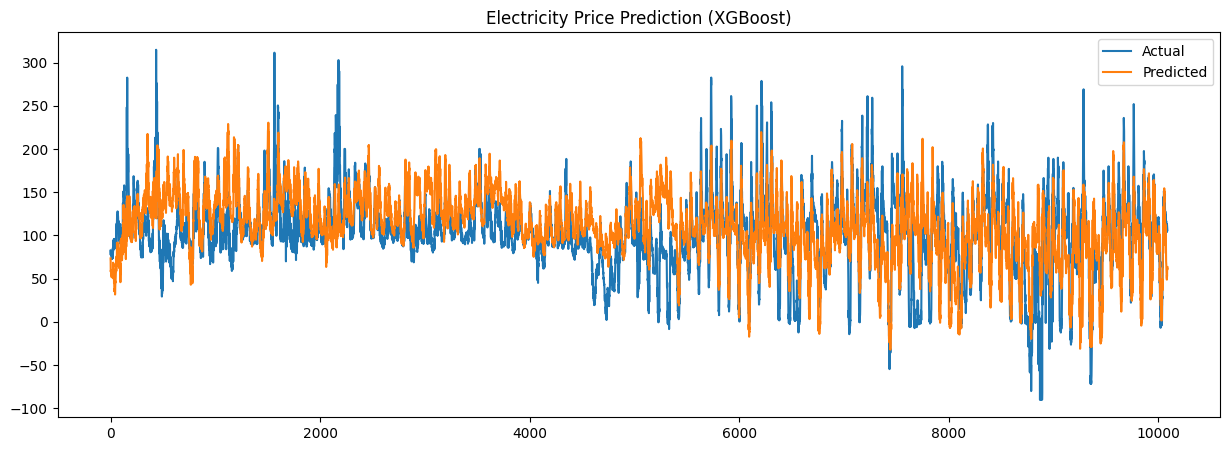

In [111]:
plt.figure(figsize=(15,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Electricity Price Prediction (XGBoost)")
plt.show()

In [138]:
df_oil_gas.head()

,DateTime(UTC),WTI_Oil,Brent_Oil,Natural_Gas,wti_roll_mean_672,brent_roll_mean_672,gas_roll_mean_672,wti_roll_std_672,brent_roll_std_672,gas_roll_std_672,wti_lag_672,brent_lag_672,gas_lag_672
0,2021-12-31 00:15:00,75.33,77.24,3.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-12-31 00:30:00,75.33,77.24,3.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-12-31 00:45:00,75.33,77.24,3.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-12-31 01:00:00,75.33,77.24,3.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-12-31 01:15:00,75.33,77.24,3.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
